# Resolução do Case: Estágio em Dados Ismart
**Autor:** João Lucas de Lima Souza

Esta é a análise da base de dados referente à Prova Única (PU) de 2023, abrangendo os cadernos de Ciências Humanas (CH), Ciências da Natureza (CN), Matemática (MA) e Linguagens (LI).

### Preparação do Ambiente e Higienização de Dados
Nesta etapa inicial, foi feito o carregamento das bibliotecas necessárias e da base de dados bruta. 

Foi identificado a inconsistência na nomenclatura das cidades (ex: "SP", "SÃO PAULO" e "São Paulo"). Para garantir a precisão estatística e evitar a distorção dos resultados, foi aplicado um mapeamento de padronização, consolidando todas as entradas sob nomes únicos para cada praça de atuação.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Carrega a base de dados
df = pd.read_excel("../data/Base_Estag_Dados.xlsx", sheet_name='Base_Prova_Unica')

# Padronizando os nomes das Praças para evitar distorções
mapeamento_pracas = {
    'SÃO PAULO': 'SP', 
    'São Paulo': 'SP',
    'SP': 'SP',
    'Belo Horizonte': 'BH', 
    'BH': 'BH',
    'Rio de Janeiro': 'RJ', 
    'RJ': 'RJ'
}
# Cria uma nova coluna 'PRACA_LIMPA' com os nomes padronizados
df['PRACA_LIMPA'] = df['PRACA'].replace(mapeamento_pracas)

## Bloco 1: Estruturação da Base de Dados
O objetivo é construir uma base analítica onde cada aluno aparece uma única vez. 

**Observação:** Devido ao volume de dados (2.553 registros), este exbição apresenta apenas as primeiras linhas. O banco de dados completo e higienizado foi exportado automaticamente e está disponível dentro da pasta **`data`** no ficheiro **`Resultado_Bloco1_Ismart.xlsx`** anexo ao repositório no GitHub para visualização completa.

In [ ]:
# 1. Isola os dados fixos do aluno 
df_perfil = df.sort_values(by='NOME COMPLETO', na_position='last')[['RA', 'NOME COMPLETO', 'ORIGEM', 'PRACA_LIMPA']].drop_duplicates(subset=['RA'])
df_perfil = df_perfil.rename(columns={'PRACA_LIMPA': 'PRACA'})

# 2. Separa as colunas 
colunas_variaveis = [col for col in df.columns if col not in ['NOME COMPLETO', 'ORIGEM', 'PRACA', 'PRACA_LIMPA']]

# 3. Pivota TODAS essas colunas por ÁREA
df_pivotado = df.pivot_table(
    index='RA', 
    columns='ÁREA', 
    values=[col for col in colunas_variaveis if col not in ['RA', 'ÁREA']], 
    aggfunc='first'
)

# 4. Arruma os nomes das colunas novas
df_pivotado.columns = [f"{col[0]}_{col[1]}" for col in df_pivotado.columns]
df_pivotado = df_pivotado.reset_index()

# 5. Junta o Perfil do aluno com as notas
df_bloco1_completo = pd.merge(df_perfil, df_pivotado, on='RA', how='left')

df_bloco1_completo['RA'] = df_bloco1_completo['RA'].astype(str)

cols_numericas = df_bloco1_completo.select_dtypes(include=['float64', 'int64']).columns
df_bloco1_completo[cols_numericas] = df_bloco1_completo[cols_numericas].round(2)

# 6. Limpeza Visual - Trocando os "NaN" por traços "-"
df_bloco1_completo = df_bloco1_completo.fillna("-")

# 7. Salva o Excel
df_bloco1_completo.to_excel("../data/Resultado_Bloco_Ismart.xlsx", index=False)

df_bloco1_completo.head()

,RA,NOME COMPLETO,ORIGEM,PRACA,C01_CH,C01_CN,C01_LI,C01_MA,C02_CH,C02_CN,...,Nivel_ENEM_LI,Nivel_ENEM_MA,Nivel_ENEM_Projetado_CH,Nivel_ENEM_Projetado_CN,Nivel_ENEM_Projetado_LI,Nivel_ENEM_Projetado_MA,PROFICIÊNCIAS_CH,PROFICIÊNCIAS_CN,PROFICIÊNCIAS_LI,PROFICIÊNCIAS_MA
0,2023039942,ADAM,IOL,SJC,-,-,0.00,0.5,-,-,...,1.0,2.0,-,-,2.0,3.0,-,-,-1.40,0.16
1,202127204,ADHAM,IOL,SJC,0.4,0.5,0.50,0.25,0.8,0.25,...,3.0,4.0,3.0,3.0,4.0,4.0,-0.02,-0.64,-0.00,0.55
2,202134077,ADRIANO,IOL,RJ,0.67,0.2,0.43,0.29,1.0,1.0,...,3.0,3.0,5.0,3.0,4.0,4.0,1.09,-0.51,0.18,-0.05
3,3585,ADRIEL,EB,RJ,0.67,0.4,0.71,0.57,0.75,1.0,...,4.0,4.0,4.0,5.0,4.0,4.0,0.7,1.39,0.75,0.81
4,202214666,ADRIELE,IOL,SJC,-,-,0.50,0.5,-,-,...,2.0,2.0,-,-,3.0,3.0,-,-,-0.04,0.29


## Bloco 2: Análise de Desempenho e Correlação

### 1. Análise de Correlação entre as Notas
**Pergunta:** Há alguma correlação entre as três diferentes notas da Prova (NOTA DESEMPENHO, Media_ENEM e ENEM_Projetado)?

Para responder a esta questão, foi utilizado o **Coeficiente de Correlação de Pearson**. Esta é uma medida estatística que varia de -1 a +1 e indica o grau de relacionamento linear entre duas variáveis:

* **Próximo a +1:** Indica uma correlação positiva forte (quando uma nota sobe, a outra também sobe).
* **Próximo a 0:** Indica que não há relação entre as notas.


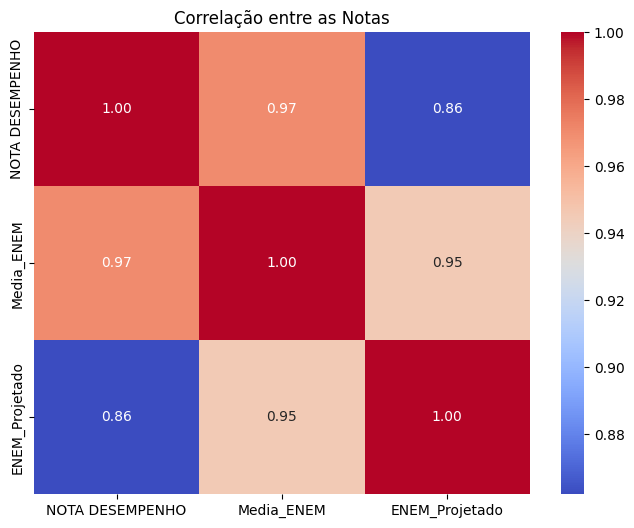

In [ ]:

colunas_notas = ['NOTA DESEMPENHO', 'Media_ENEM', 'ENEM_Projetado']
# Calcula a relação entre as notas 
matriz_correlacao = df[colunas_notas].corr() 

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlação entre as Notas')
plt.show();

**Conclusão:** Observa-se uma **correlação positiva muito forte** com valores variando de 0.86 a 0.97 entre as três métricas. Isso indica que, embora as notas possuam escalas diferentes, elas apresentam alta consistência entre si.

---
### 2. Média de Enem Projetado por Praça (2023)


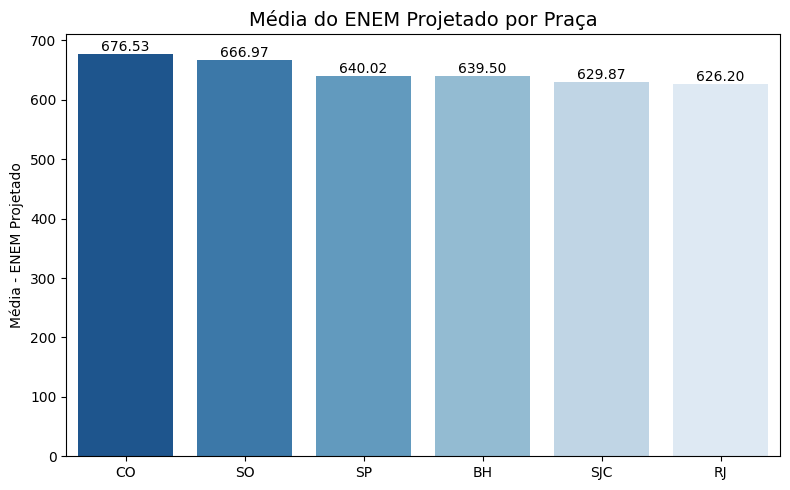

In [ ]:
# SP - SÃO PAULO, BH - BELO HORIZONTE, RJ - RIO DE JANEIRO
# CO - COTIA, SJC - SÃO JOSÉ DOS CAMPOS, SO - SOROCABA

# Exibe o gráfico
media_por_praca_limpa = df.groupby('PRACA_LIMPA')['ENEM_Projetado'].mean().reset_index()

# Calcula e ordena as médias 
media_por_praca_limpa = media_por_praca_limpa.sort_values(by='ENEM_Projetado', ascending=False).reset_index(drop=True)

plt.figure(figsize=(8, 5)) 

# Cria o gráfico de barras
ax = sns.barplot(data=media_por_praca_limpa, 
                 x='PRACA_LIMPA', 
                 y='ENEM_Projetado', 
                 hue='PRACA_LIMPA', 
                 palette='Blues_r', 
                 legend=False)

plt.title('Média do ENEM Projetado por Praça', fontsize=14)
plt.ylabel('Média - ENEM Projetado')
plt.xlabel('') 
plt.xticks(rotation=0) 

# Exibe os valores exatos no topo de cada barra
for index, row in media_por_praca_limpa.iterrows():
    ax.text(index, row['ENEM_Projetado'] + 5, f"{row['ENEM_Projetado']:.2f}", color='black', ha="center", fontsize=10)

plt.tight_layout()
plt.show();

Conforme o gráfico acima, a praça com maior média de ENEM PROJETADO em 2023 é **Cotia (CO)**
---
### 3. Análise Exploratória e Ações Sugeridas
Para extrair insights práticos que gerem valor, cruzamos o desempenho médio de cada Praça por Área do Conhecimento.

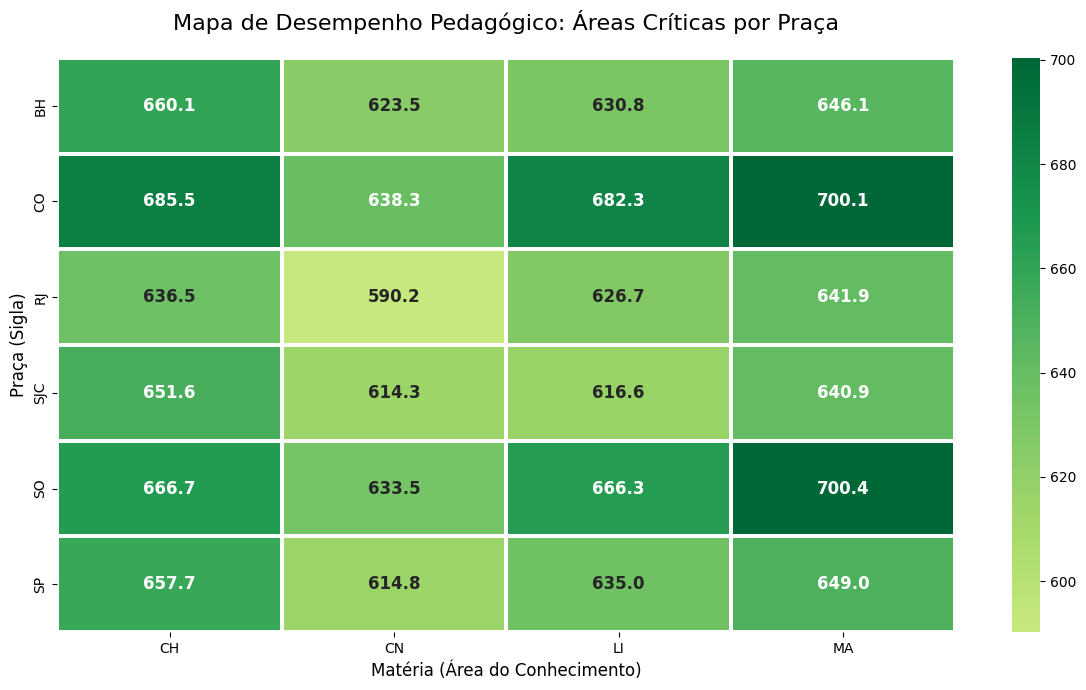

In [ ]:
#SP - SÃO PAULO, BH - BELO HORIZONTE, RJ - RIO DE JANEIRO
#CO - COTIA, SJC - SÃO JOSÉ DOS CAMPOS, SO - SOROCABA

# Recriando a tabela do heatmap com as siglas
media_praca_area = df.pivot_table(index='PRACA_LIMPA', columns='ÁREA', values='ENEM_Projetado', aggfunc='mean')

plt.figure(figsize=(12, 7))

# Heatmap com siglas e cores ajustadas
sns.heatmap(media_praca_area, 
            annot=True, 
            cmap='RdYlGn', 
            center=550,  
            fmt=".1f", 
            linewidths=1.5, 
            linecolor='white',
            annot_kws={"size": 12, "weight": "bold"})

plt.title('Mapa de Desempenho Pedagógico: Áreas Críticas por Praça', fontsize=16, pad=20)
plt.xlabel('Matéria (Área do Conhecimento)', fontsize=12)
plt.ylabel('Praça (Sigla)', fontsize=12)
plt.tight_layout()
plt.show();

#### Conclusões Estratégicas para o Time:

1. **Situação Crítica em Matemática (SJC e RJ):** Os dados revelam que a praça de **São José dos Campos (SJC)** apresenta a menor média em Matemática (MA) de toda a rede, seguida de perto pelo **Rio de Janeiro (RJ)**. São Paulo (SP) também demonstra fragilidade em Ciências da Natureza (CN).
   * **Ação:** Implementar um plano de reforço acadêmico intensivo em disciplinas de exatas com foco prioritário em SJC e RJ, onde o sinal de alerta é mais severo.


2. **Destaque de Performance (Cotia - CO):** A praça de **Cotia** apresenta o melhor desempenho médio da rede em 2023, liderando com as maiores notas em praticamente todas as áreas do conhecimento.
   * **Ação:** Identificar quais práticas pedagógicas estão sendo aplicadas em Cotia que podem ser escaladas para as outras unidades da rede.